In [ ]:
# Seasonal Agriculture Performance Analysis

## Major Project

### VOIS AICTE Batch 1
### Academic Year 2026–2027


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [15]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv


In [17]:
import os

print(os.listdir())

['.config', 'seasonal_agriculture_performance_dataset.csv', 'sample_data']


In [18]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

In [19]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


The dataset contains agricultural information related to farms,
crops, seasons, environmental conditions, resource usage,
production, and economic performance.

The analysis focuses on understanding how these variables
change across different agricultural seasons.

In [20]:
print("Dataset Shape:", df.shape)

Dataset Shape: (4000, 28)


In [21]:
print("Dataset Columns:\n")

for column in df.columns:
    print(column)

Dataset Columns:

Farm_ID
State
District
Crop
Season
Farm_Area_Hectares
Rainfall_mm
Avg_Temperature_C
Humidity_pct
Sunlight_Hours_Day
Soil_pH
Soil_Moisture_pct
Nitrogen_kg_ha
Phosphorus_kg_ha
Potassium_kg_ha
Irrigation_Method
Fertilizer_kg_ha
Pesticide_Litre_ha
Seed_Quality_Score
Yield_Tonnes_Ha
Production_Tonnes
Market_Price_INR_Tonne
Total_Cost_INR
Revenue_INR
Profit_INR
Water_Used_m3
Water_Efficiency_t_per_1000m3
Disease_Pest_Risk_pct


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [23]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [24]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [25]:
missing = df.isnull().sum()

missing[missing > 0]

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [26]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


In [27]:
df_clean = df.copy()

In [28]:
df_clean.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [29]:
numerical_columns = df_clean.select_dtypes(
    include=np.number
).columns

for column in numerical_columns:
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].median()
    )

In [30]:
categorical_columns = df_clean.select_dtypes(
    include="object"
).columns

for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].mode()[0]
    )

In [31]:
print("Missing Values After Cleaning:")

print(df_clean.isnull().sum().sum())

Missing Values After Cleaning:
0


In [32]:
print("Final Dataset Shape:")

print(df_clean.shape)

Final Dataset Shape:
(4000, 28)


In [33]:
df_clean.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


Exploratory Data Analysis is performed to understand
the distribution of agricultural activities, crops,
seasons, regions and farming conditions.

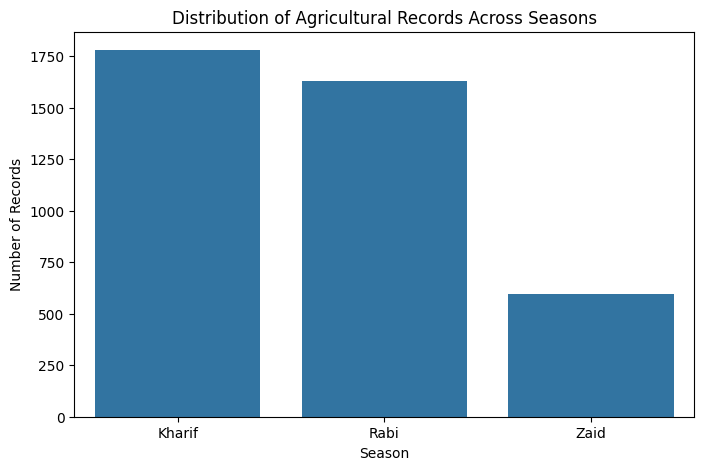

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="Season"
)

plt.title("Distribution of Agricultural Records Across Seasons")

plt.xlabel("Season")

plt.ylabel("Number of Records")

plt.show()

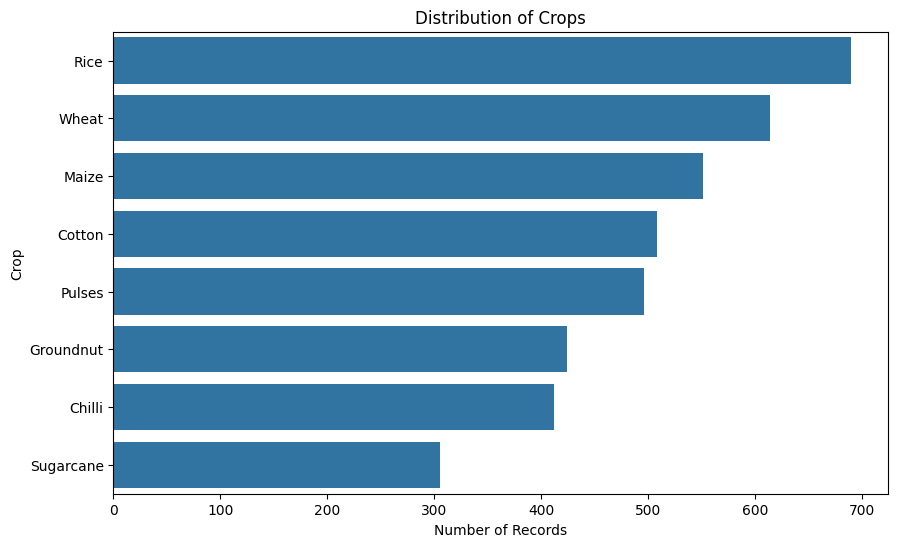

In [35]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df_clean,
    y="Crop",
    order=df_clean["Crop"].value_counts().index
)

plt.title("Distribution of Crops")

plt.xlabel("Number of Records")

plt.ylabel("Crop")

plt.show()


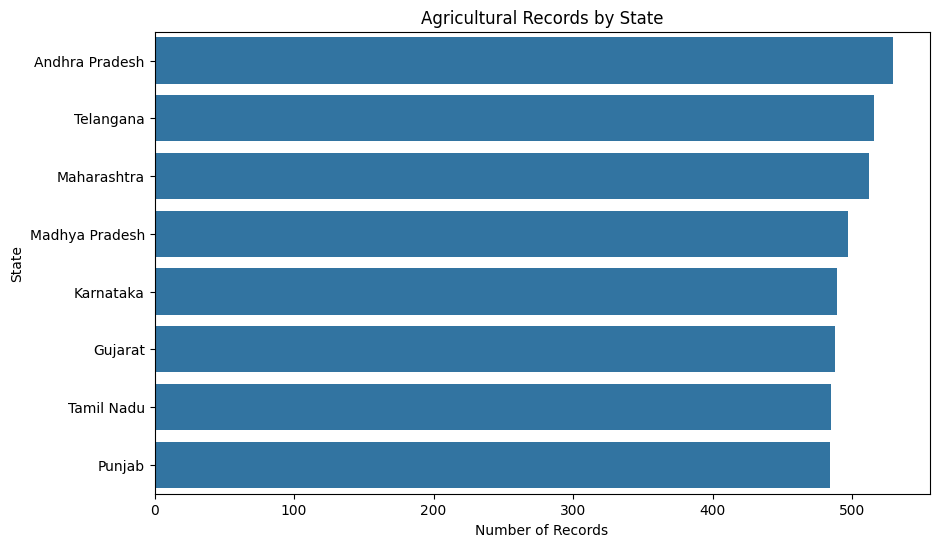

In [36]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df_clean,
    y="State",
    order=df_clean["State"].value_counts().index
)

plt.title("Agricultural Records by State")

plt.xlabel("Number of Records")

plt.ylabel("State")

plt.show()

AVERAGE YIELD BY SEASON


In [37]:
season_yield = df_clean.groupby("Season")[
    "Yield_Tonnes_Ha"
].mean()

print(season_yield)


Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


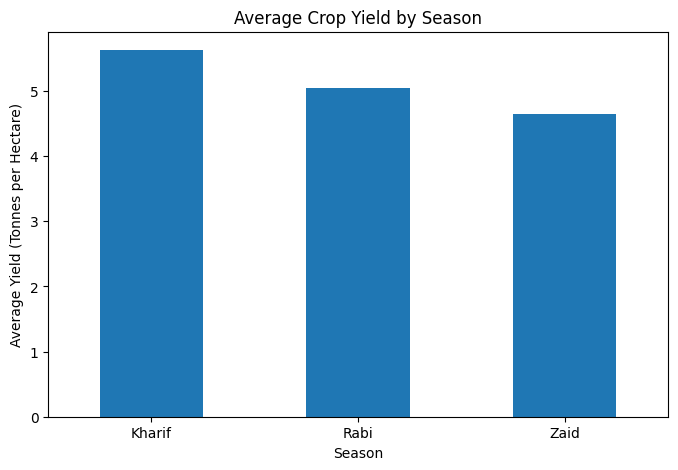

In [38]:
season_yield.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Crop Yield by Season")

plt.xlabel("Season")

plt.ylabel("Average Yield (Tonnes per Hectare)")

plt.xticks(rotation=0)

plt.show()

AVERAGE PRODUCTION BY SEASON

In [39]:
season_production = df_clean.groupby("Season")[
    "Production_Tonnes"
].mean()

print(season_production)

Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64


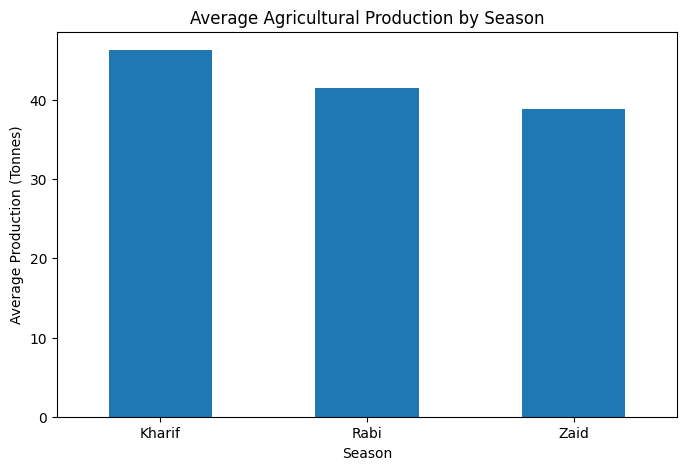

In [40]:
season_production.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Agricultural Production by Season")

plt.xlabel("Season")

plt.ylabel("Average Production (Tonnes)")

plt.xticks(rotation=0)

plt.show()

SEASONAL PERFORMANCE TABLE

In [41]:
season_performance = df_clean.groupby("Season").agg({

    "Yield_Tonnes_Ha": "mean",

    "Production_Tonnes": "mean",

    "Revenue_INR": "mean",

    "Profit_INR": "mean",

    "Water_Efficiency_t_per_1000m3": "mean"

}).round(2)

season_performance

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Efficiency_t_per_1000m3
Season,,,,,
Kharif,5.63,46.31,710719.06,178914.65,5.89
Rabi,5.04,41.49,601526.05,87689.47,5.19
Zaid,4.64,38.89,519171.90,-24804.82,4.41


ENVIRONMENT ANALYSIS
Agricultural performance is influenced by environmental
conditions such as rainfall, temperature, humidity,
sunlight and soil moisture.

This section investigates the relationship between
environmental variables and agricultural outcomes.

RAINFALL BY SEASON

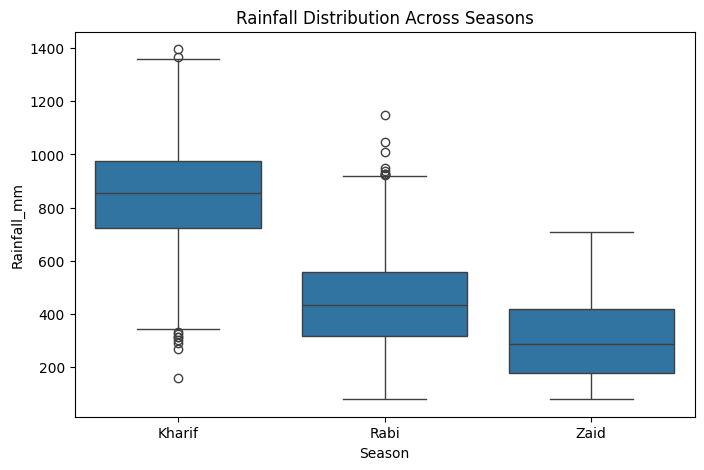

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Rainfall_mm"
)

plt.title("Rainfall Distribution Across Seasons")

plt.show()

TEMPARATURE BY SEASON

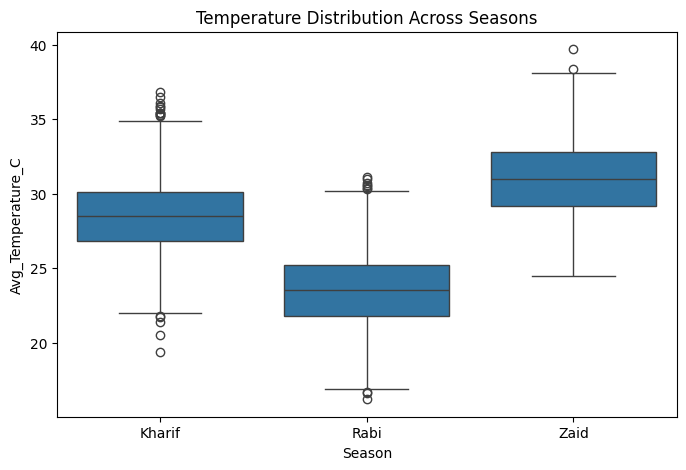

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Avg_Temperature_C"
)

plt.title("Temperature Distribution Across Seasons")

plt.show()

HUMIDIDTY BY SEASON

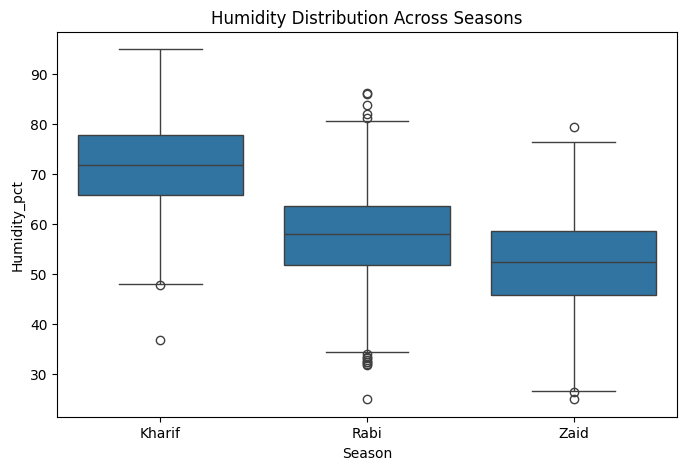

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Humidity_pct"
)

plt.title("Humidity Distribution Across Seasons")

plt.show()

RAINFALL VS PRODUCTION

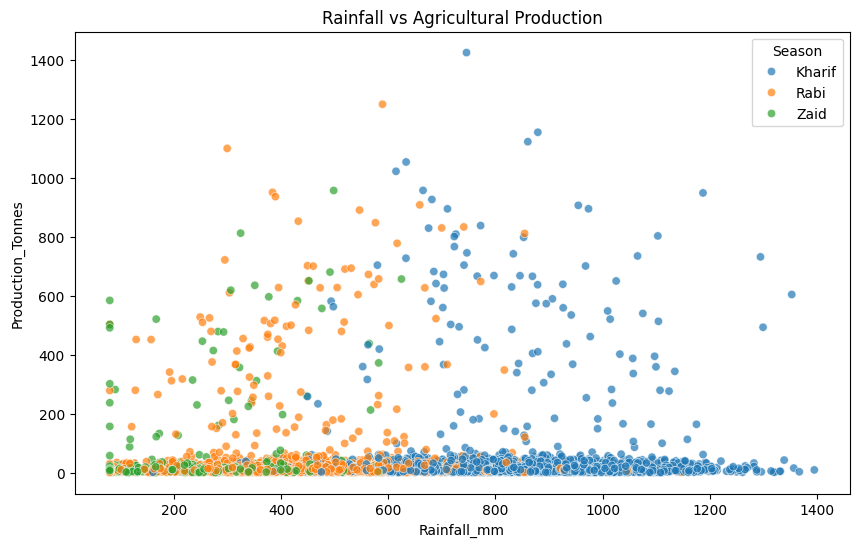

In [45]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x="Rainfall_mm",
    y="Production_Tonnes",
    hue="Season",
    alpha=0.7
)

plt.title("Rainfall vs Agricultural Production")

plt.show()

TEMPARATURE AND YIELD

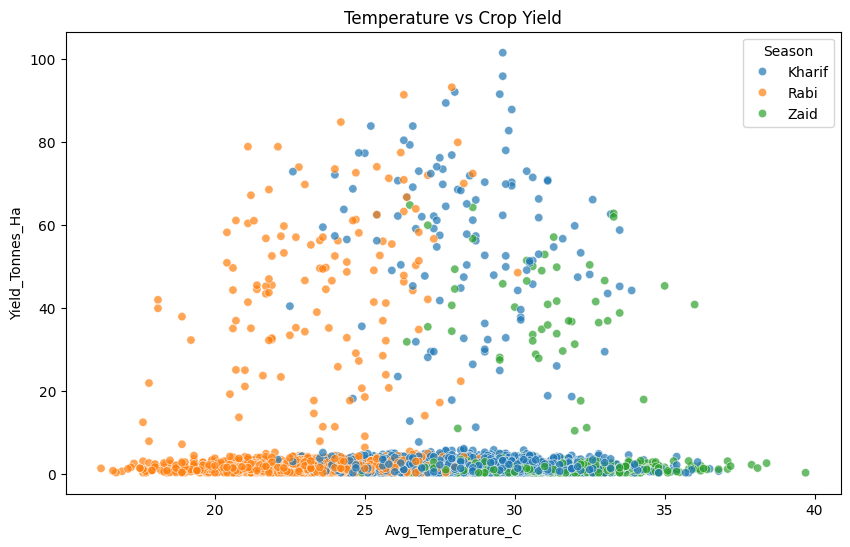

In [46]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)

plt.title("Temperature vs Crop Yield")

plt.show()

RESOURCE USAGE ANALYSIS
This analysis examines how agricultural resources
such as water, fertilizer, pesticides and nutrients
are used across different seasons.

In [47]:
water_season = df_clean.groupby("Season")[
    "Water_Used_m3"
].mean()

water_season

,Water_Used_m3
Season,
Kharif,6102.201237
Rabi,5846.987093
Zaid,6419.893939


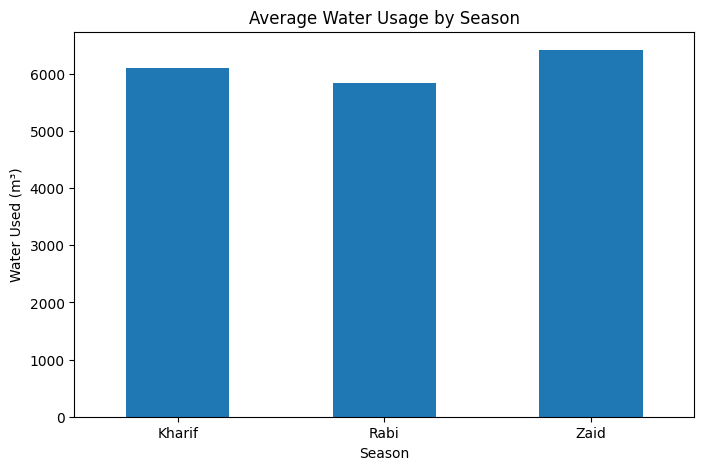

In [48]:
water_season.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Water Usage by Season")

plt.xlabel("Season")

plt.ylabel("Water Used (m³)")

plt.xticks(rotation=0)

plt.show()

WATER EFFICENCY BY SEASON


In [49]:
water_efficiency = df_clean.groupby("Season")[
    "Water_Efficiency_t_per_1000m3"
].mean()

water_efficiency

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.891834
Rabi,5.186122
Zaid,4.413239


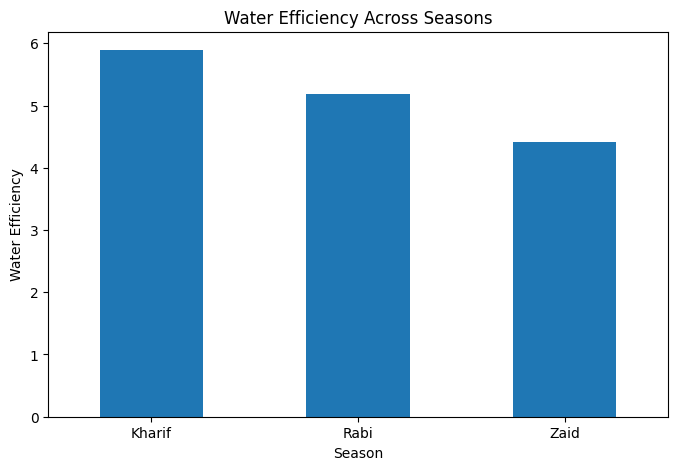

In [50]:
water_efficiency.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Water Efficiency Across Seasons")

plt.xlabel("Season")

plt.ylabel("Water Efficiency")

plt.xticks(rotation=0)

plt.show()

FERTILIZER USAGE BY SEASON

In [51]:
fertilizer = df_clean.groupby("Season")[
    "Fertilizer_kg_ha"
].mean()

fertilizer

,Fertilizer_kg_ha
Season,
Kharif,187.077965
Rabi,185.407068
Zaid,184.638047


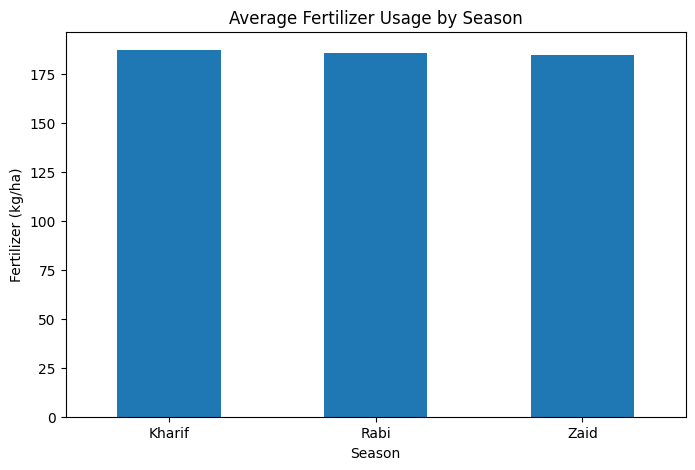

In [52]:
fertilizer.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Fertilizer Usage by Season")

plt.xlabel("Season")

plt.ylabel("Fertilizer (kg/ha)")

plt.xticks(rotation=0)

plt.show()

FERTILIZER USAGE BY SEASSON

In [53]:
fertilizer = df_clean.groupby("Season")[
    "Fertilizer_kg_ha"
].mean()

fertilizer

,Fertilizer_kg_ha
Season,
Kharif,187.077965
Rabi,185.407068
Zaid,184.638047


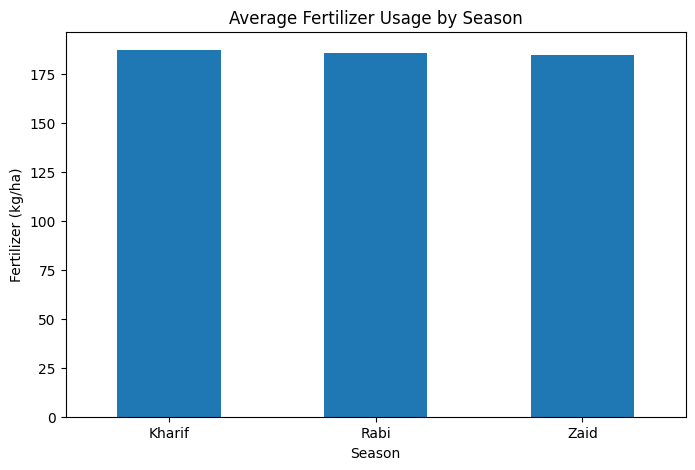

In [54]:
fertilizer.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Fertilizer Usage by Season")

plt.xlabel("Season")

plt.ylabel("Fertilizer (kg/ha)")

plt.xticks(rotation=0)

plt.show()

ECONOMIC PERFORMANCE ANALYSIS
Economic performance is analyzed using revenue,
total cost, market price and profit.

The objective is to identify how agricultural
economic outcomes vary across seasons.

In [55]:
revenue = df_clean.groupby("Season")[
    "Revenue_INR"
].mean()

revenue



,Revenue_INR
Season,
Kharif,710719.055649
Rabi,601526.048556
Zaid,519171.904040


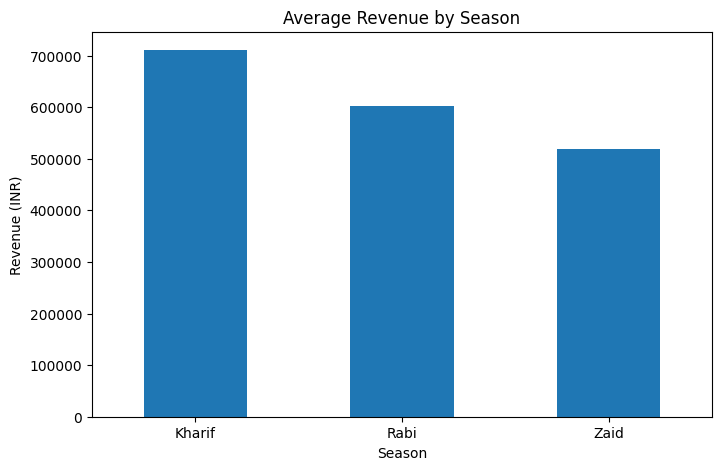

In [56]:
revenue.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Revenue by Season")

plt.xlabel("Season")

plt.ylabel("Revenue (INR)")

plt.xticks(rotation=0)

plt.show()

PROFIT BY SEASON

In [57]:
profit = df_clean.groupby("Season")[
    "Profit_INR"
].mean()

profit

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


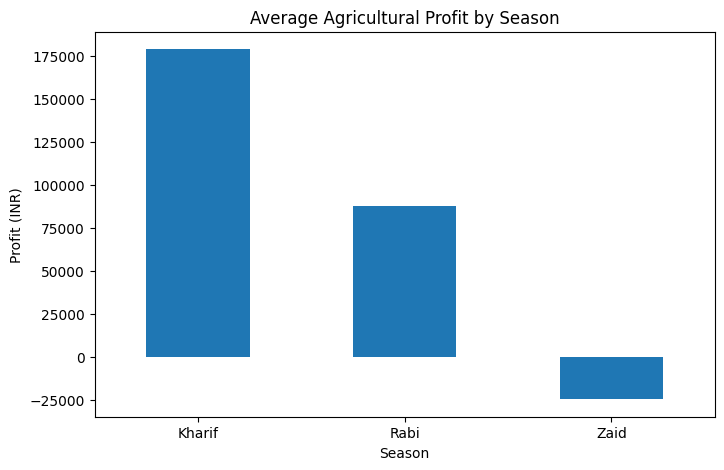

In [58]:
profit.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Agricultural Profit by Season")

plt.xlabel("Season")

plt.ylabel("Profit (INR)")

plt.xticks(rotation=0)

plt.show()

COST VS REVENUE


In [59]:
economic = df_clean.groupby("Season").agg({

    "Total_Cost_INR": "mean",

    "Revenue_INR": "mean"

})

economic

,Total_Cost_INR,Revenue_INR
Season,,
Kharif,531804.408094,710719.055649
Rabi,513836.578365,601526.048556
Zaid,543976.728956,519171.904040


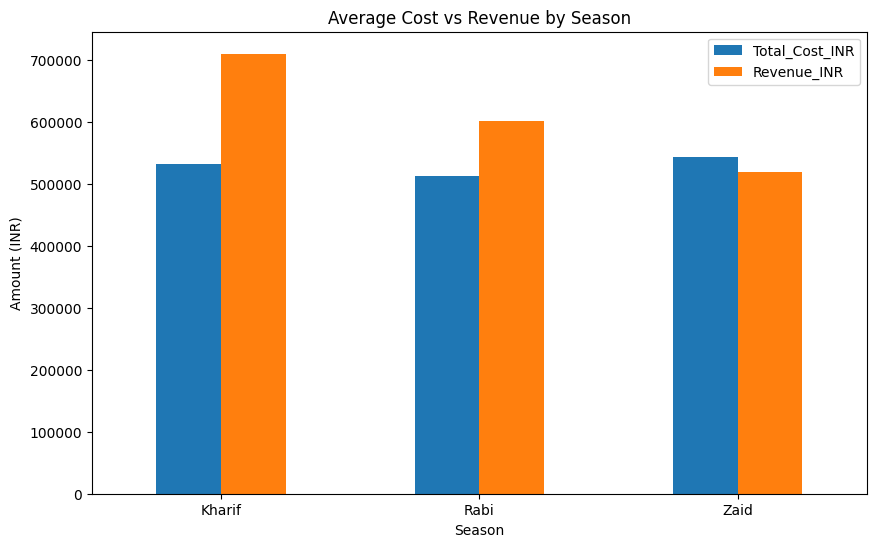

In [60]:
economic.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Cost vs Revenue by Season")

plt.xlabel("Season")

plt.ylabel("Amount (INR)")

plt.xticks(rotation=0)

plt.show()

REGIONAL AGRICULTURAL PERFORMANCE
This analysis compares agricultural performance
across different states and districts.

In [61]:
state_production = df_clean.groupby("State")[
    "Production_Tonnes"
].mean().sort_values(
    ascending=False
)

state_production

,Production_Tonnes
State,
Punjab,52.233099
Gujarat,48.331988
Karnataka,47.732720
Maharashtra,43.984043
Tamil Nadu,40.840371
Telangana,39.254186
Madhya Pradesh,37.559517
Andhra Pradesh,36.913157


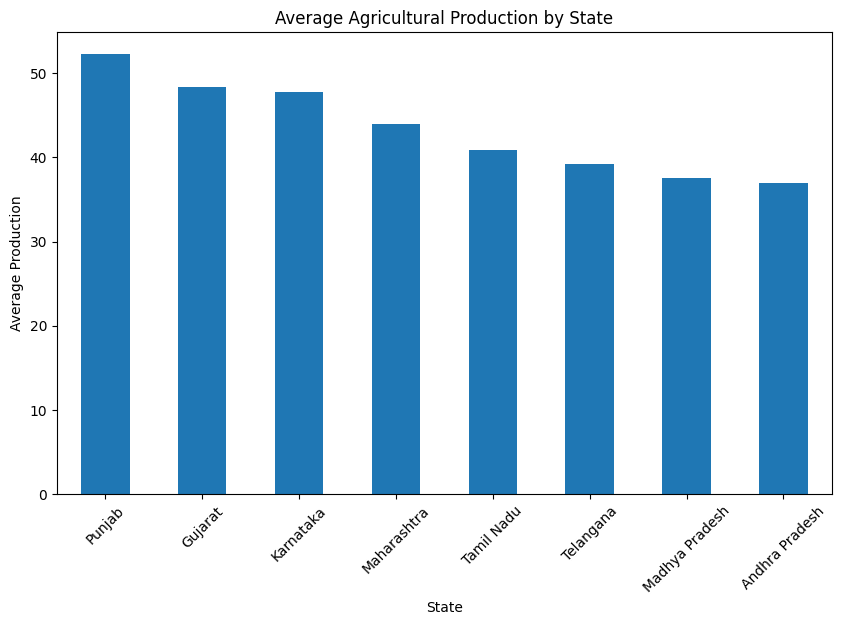

In [62]:
state_production.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Agricultural Production by State")

plt.xlabel("State")

plt.ylabel("Average Production")

plt.xticks(rotation=45)

plt.show()

PROFIT BY STATE

In [63]:
state_profit = df_clean.groupby("State")[
    "Profit_INR"
].mean().sort_values(
    ascending=False
)

state_profit

,Profit_INR
State,
Punjab,136025.636364
Maharashtra,135428.855469
Karnataka,119422.335378
Tamil Nadu,117744.748454
Gujarat,117568.235656
Telangana,108829.616279
Madhya Pradesh,86840.756539
Andhra Pradesh,73453.527410


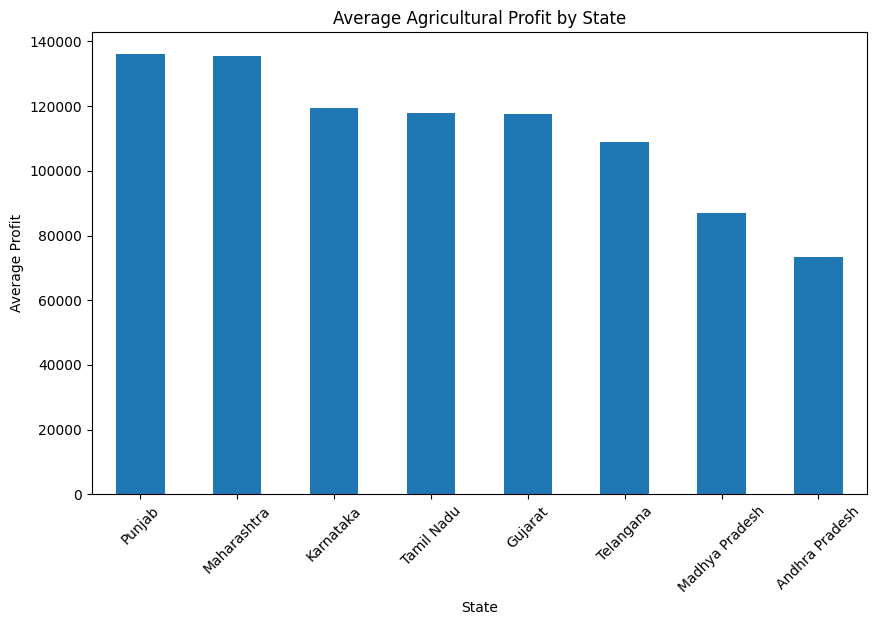

In [64]:
state_profit.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Agricultural Profit by State")

plt.xlabel("State")

plt.ylabel("Average Profit")

plt.xticks(rotation=45)

plt.show()

CROP PERFORMANCE ANALYISIS
This section compares agricultural performance
across different crops and seasons.

In [65]:
crop_yield = df_clean.groupby("Crop")[
    "Yield_Tonnes_Ha"
].mean().sort_values(
    ascending=False
)

crop_yield

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.642361
Maize,2.710036
Rice,2.431304
Wheat,2.108013
Chilli,1.542767
Groundnut,1.322901
Cotton,1.229783
Pulses,0.921512


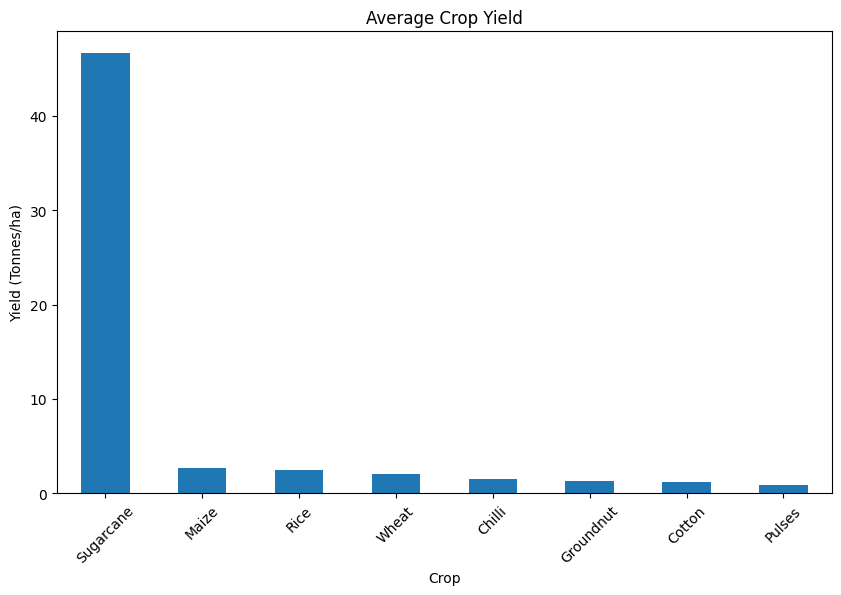

In [66]:
crop_yield.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Crop Yield")

plt.xlabel("Crop")

plt.ylabel("Yield (Tonnes/ha)")

plt.xticks(rotation=45)

plt.show()

In [67]:
crop_profit = df_clean.groupby("Crop")[
    "Profit_INR"
].mean().sort_values(
    ascending=False
)

crop_profit

,Profit_INR
Crop,
Sugarcane,817187.986885
Chilli,750878.342233
Cotton,124546.915354
Groundnut,44858.120283
Pulses,-4238.052419
Maize,-83978.326679
Rice,-102213.504348
Wheat,-123398.337134


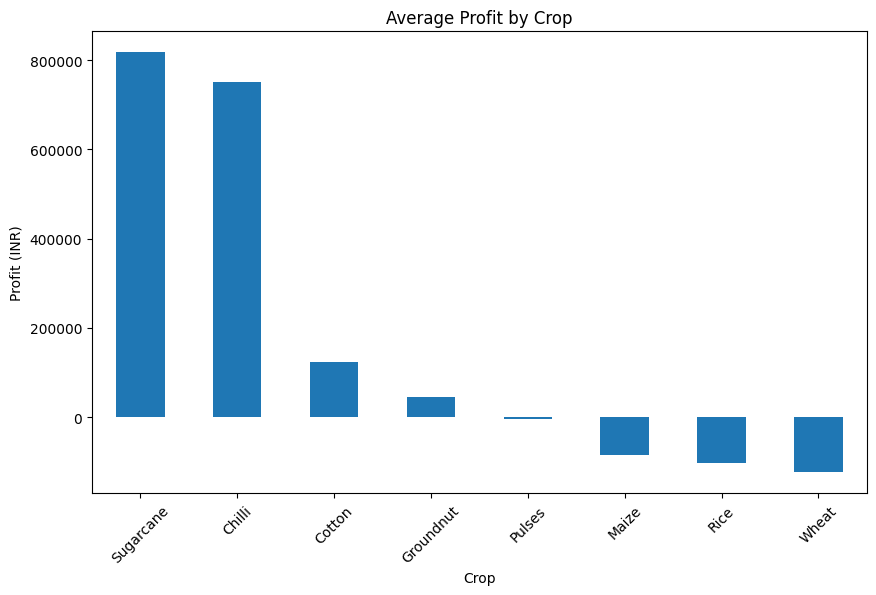

In [68]:
crop_profit.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Profit by Crop")

plt.xlabel("Crop")

plt.ylabel("Profit (INR)")

plt.xticks(rotation=45)

plt.show()

CROP PERFORMANCE BY SEASON

In [69]:
crop_season = pd.pivot_table(

    df_clean,

    values="Yield_Tonnes_Ha",

    index="Crop",

    columns="Season",

    aggfunc="mean"

)

crop_season

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588


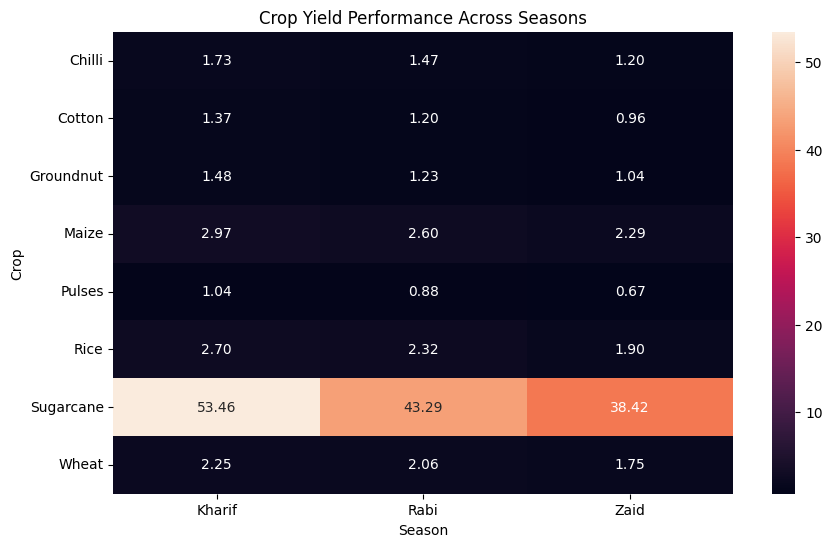

In [70]:
plt.figure(figsize=(10,6))

sns.heatmap(
    crop_season,
    annot=True,
    fmt=".2f"
)

plt.title("Crop Yield Performance Across Seasons")

plt.show()

DISEASE AND PEST RISK ANALYSIS

In [71]:
risk_season = df_clean.groupby("Season")[
    "Disease_Pest_Risk_pct"
].mean()

risk_season

,Disease_Pest_Risk_pct
Season,
Kharif,54.467903
Rabi,40.482114
Zaid,38.216667


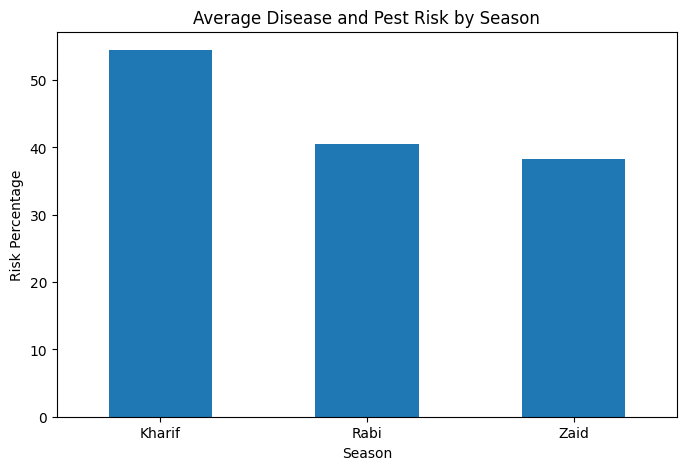

In [72]:
risk_season.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Disease and Pest Risk by Season")

plt.xlabel("Season")

plt.ylabel("Risk Percentage")

plt.xticks(rotation=0)

plt.show()

SOIL ANALYSIS

In [73]:
soil_analysis = df_clean.groupby("Season").agg({

    "Soil_pH": "mean",

    "Soil_Moisture_pct": "mean"

}).round(2)

soil_analysis

,Soil_pH,Soil_Moisture_pct
Season,,
Kharif,6.73,31.15
Rabi,6.67,24.07
Zaid,6.69,19.28


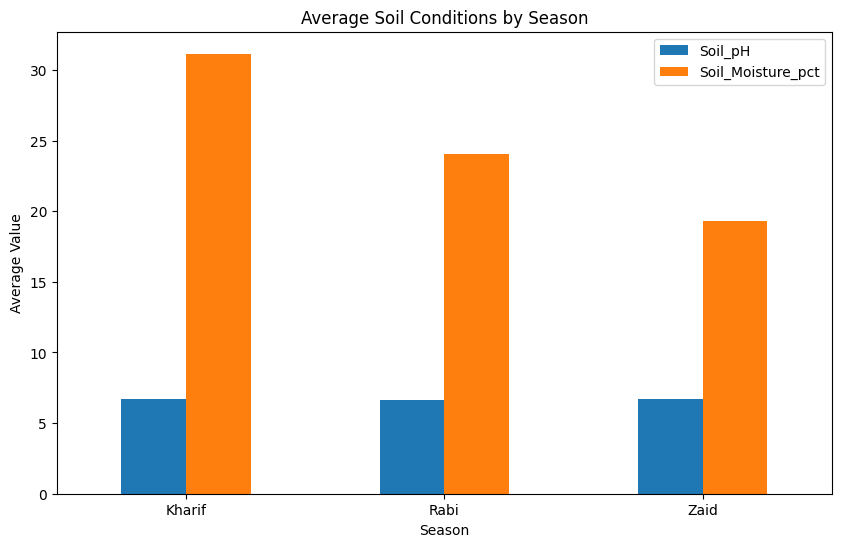

In [74]:
soil_analysis.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Soil Conditions by Season")

plt.xlabel("Season")

plt.ylabel("Average Value")

plt.xticks(rotation=0)

plt.show()

CORRELATION ANALYSIS
Correlation analysis is used to identify relationships
between environmental factors, agricultural inputs,
production and economic performance.

In [75]:
numeric_df = df_clean.select_dtypes(
    include=np.number
)

In [76]:
correlation = numeric_df.corr()

correlation

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.000000,0.007256,0.036870,0.000471,0.001821,0.009857,0.004033,0.013658,-0.006625,0.000195,...,0.015236,0.030203,0.197842,-0.021571,0.962211,0.543364,0.115241,0.576015,0.028930,0.025963
Rainfall_mm,0.007256,1.000000,0.198492,0.521069,-0.362779,0.016657,0.508941,0.007460,0.020940,0.031373,...,-0.018581,0.030951,0.024447,0.000639,0.013041,0.098146,0.107648,0.002240,0.058102,0.621762
Avg_Temperature_C,0.036870,0.198492,1.000000,0.138136,-0.033863,0.029988,0.084001,0.018707,0.008508,0.022993,...,-0.031943,0.009996,0.007346,0.002951,0.041030,0.026703,0.009043,0.022995,0.006534,0.245613
Humidity_pct,0.000471,0.521069,0.138136,1.000000,-0.297298,0.028447,0.446470,0.001198,-0.005963,-0.003070,...,-0.045598,0.012297,0.003614,0.000262,0.006023,0.057358,0.063775,-0.002086,0.026169,0.545093
Sunlight_Hours_Day,0.001821,-0.362779,-0.033863,-0.297298,1.000000,-0.017806,-0.302846,0.009920,0.001544,-0.014407,...,0.021257,-0.015341,-0.023504,-0.000696,-0.000655,-0.047216,-0.054822,-0.005717,-0.021386,-0.253251
Soil_pH,0.009857,0.016657,0.029988,0.028447,-0.017806,1.000000,0.031183,0.006286,0.016620,-0.019407,...,-0.004181,-0.020672,-0.012512,0.022226,0.005302,-0.008798,-0.013145,-0.022859,-0.010087,0.031141
Soil_Moisture_pct,0.004033,0.508941,0.084001,0.446470,-0.302846,0.031183,1.000000,0.008884,0.013406,0.007796,...,-0.019556,0.010999,0.004787,0.016914,0.002741,0.079380,0.091281,0.003183,0.027776,0.375547
Nitrogen_kg_ha,0.013658,0.007460,0.018707,0.001198,0.009920,0.006286,0.008884,1.000000,0.010199,0.010490,...,0.014896,0.053149,0.048182,-0.022595,0.011900,0.078252,0.085016,0.022127,0.054896,-0.011503
Phosphorus_kg_ha,-0.006625,0.020940,0.008508,-0.005963,0.001544,0.016620,0.013406,0.010199,1.000000,0.002847,...,-0.007575,0.047941,0.034957,-0.005174,-0.016508,0.034940,0.049747,-0.000752,0.057129,0.032061
Potassium_kg_ha,0.000195,0.031373,0.022993,-0.003070,-0.014407,-0.019407,0.007796,0.010490,0.002847,1.000000,...,0.006862,0.003382,0.004472,0.007572,0.003431,0.028278,0.031192,0.001667,0.006575,0.013403


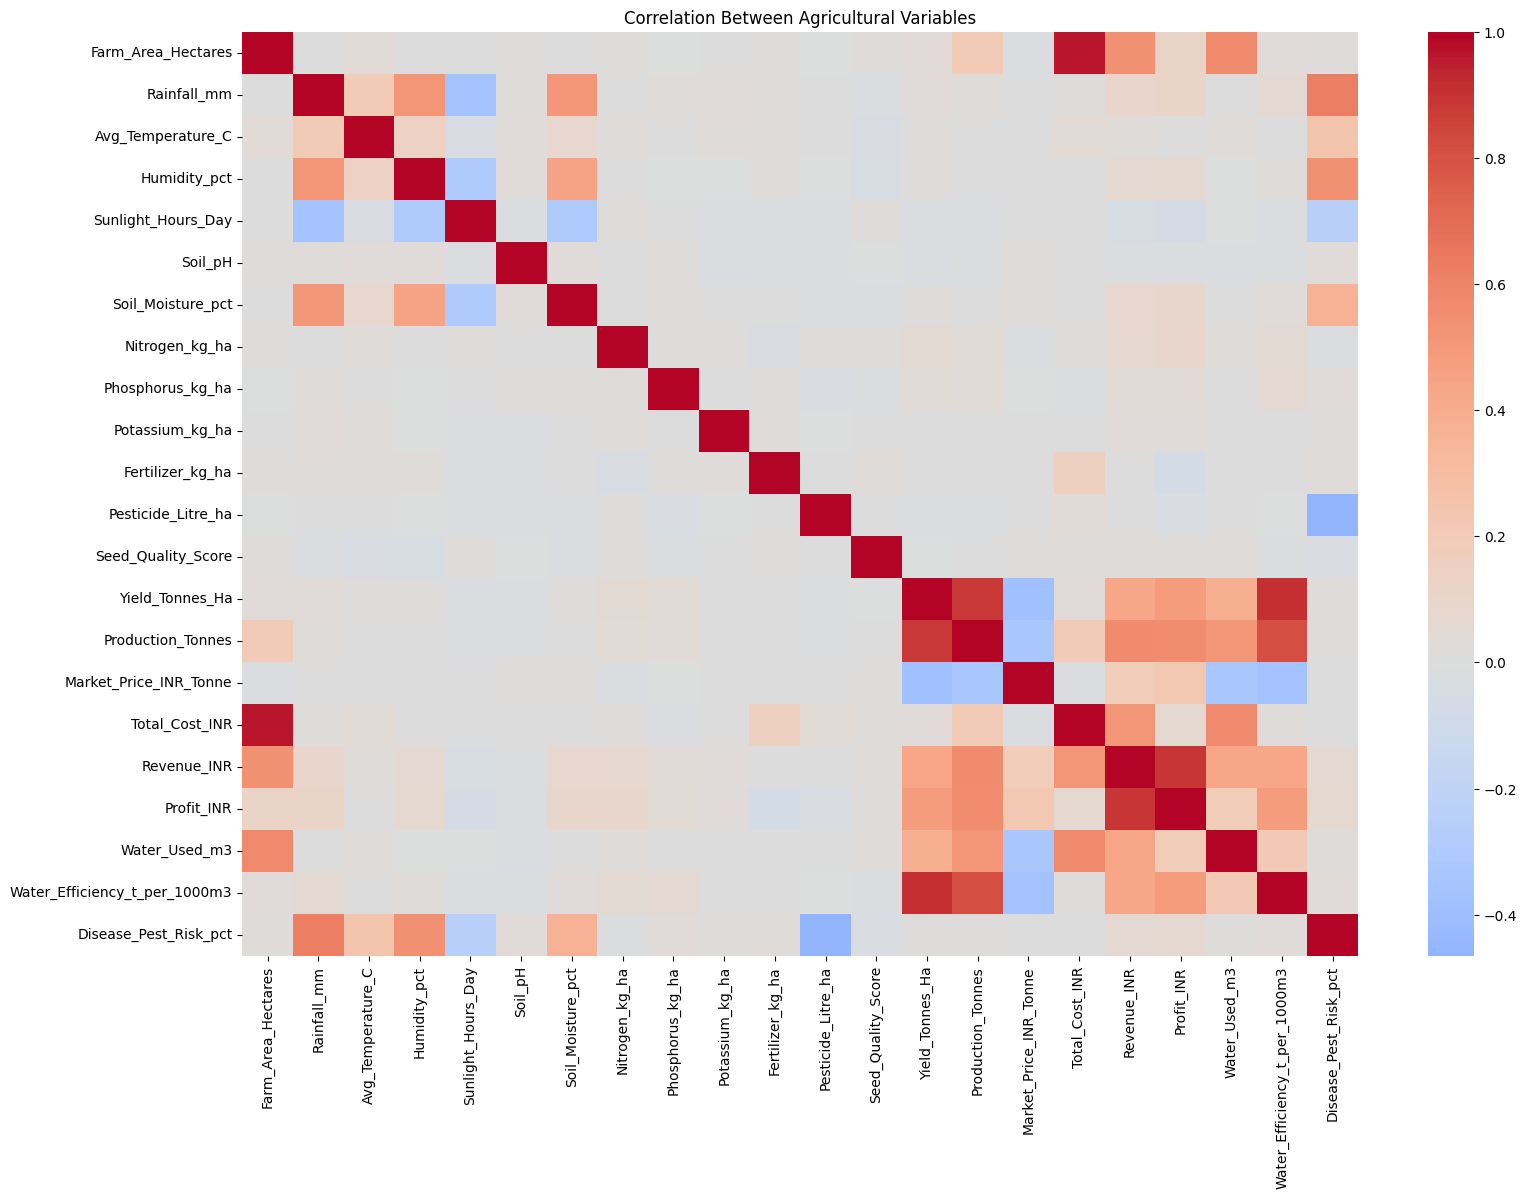

In [77]:
plt.figure(figsize=(18,12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Between Agricultural Variables"
)

plt.show()

In [78]:
yield_correlation = correlation[
    "Yield_Tonnes_Ha"
].sort_values(
    ascending=False
)

yield_correlation

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Total_Cost_INR,0.030622


In [79]:
profit_correlation = correlation[
    "Profit_INR"
].sort_values(
    ascending=False
)

profit_correlation

,Profit_INR
Profit_INR,1.000000
Revenue_INR,0.887331
Production_Tonnes,0.554172
Water_Efficiency_t_per_1000m3,0.489487
Yield_Tonnes_Ha,0.488466
Market_Price_INR_Tonne,0.225119
Water_Used_m3,0.190278
Farm_Area_Hectares,0.115241
Rainfall_mm,0.107648
Soil_Moisture_pct,0.091281


CREATE A SEASONAL DASHBOARD TABLE

In [80]:
dashboard = df_clean.groupby("Season").agg({

    "Rainfall_mm": "mean",

    "Avg_Temperature_C": "mean",

    "Yield_Tonnes_Ha": "mean",

    "Production_Tonnes": "mean",

    "Water_Used_m3": "mean",

    "Water_Efficiency_t_per_1000m3": "mean",

    "Revenue_INR": "mean",

    "Profit_INR": "mean",

    "Disease_Pest_Risk_pct": "mean"

}).round(2)

dashboard

,Rainfall_mm,Avg_Temperature_C,Yield_Tonnes_Ha,Production_Tonnes,Water_Used_m3,Water_Efficiency_t_per_1000m3,Revenue_INR,Profit_INR,Disease_Pest_Risk_pct
Season,,,,,,,,,
Kharif,849.20,28.45,5.63,46.31,6102.20,5.89,710719.06,178914.65,54.47
Rabi,437.62,23.49,5.04,41.49,5846.99,5.19,601526.05,87689.47,40.48
Zaid,304.65,31.04,4.64,38.89,6419.89,4.41,519171.90,-24804.82,38.22


IDENTIFY BEST SEASON

In [81]:
best_yield_season = season_performance[
    "Yield_Tonnes_Ha"
].idxmax()

best_profit_season = season_performance[
    "Profit_INR"
].idxmax()

best_production_season = season_performance[
    "Production_Tonnes"
].idxmax()

print("Best Season by Yield:", best_yield_season)

print("Best Season by Production:", best_production_season)

print("Best Season by Profit:", best_profit_season)

Best Season by Yield: Kharif
Best Season by Production: Kharif
Best Season by Profit: Kharif


IDENTIFY BEST CROP

In [82]:
best_crop_yield = crop_yield.idxmax()

best_crop_profit = crop_profit.idxmax()

print("Best Crop by Yield:", best_crop_yield)

print("Best Crop by Profit:", best_crop_profit)

Best Crop by Yield: Sugarcane
Best Crop by Profit: Sugarcane


IDENTIFY BEST STATE

In [83]:
best_state_production = state_production.idxmax()

best_state_profit = state_profit.idxmax()

print("Best State by Production:", best_state_production)

print("Best State by Profit:", best_state_profit)

Best State by Production: Punjab
Best State by Profit: Punjab


FINAL RESULTS


In [84]:
print("========== FINAL PROJECT RESULTS ==========\n")

print("Best Season by Yield:", best_yield_season)
print("Best Season by Production:", best_production_season)
print("Best Season by Profit:", best_profit_season)

print("\nBest Crop by Yield:", best_crop_yield)
print("Best Crop by Profit:", best_crop_profit)

print("\nBest State by Production:", best_state_production)
print("Best State by Profit:", best_state_profit)

========== FINAL PROJECT RESULTS ==========

Best Season by Yield: Kharif
Best Season by Production: Kharif
Best Season by Profit: Kharif

Best Crop by Yield: Sugarcane
Best Crop by Profit: Sugarcane

Best State by Production: Punjab
Best State by Profit: Punjab


In [85]:
print("========== SEASONAL PERFORMANCE SUMMARY ==========\n")

display(dashboard)

========== SEASONAL PERFORMANCE SUMMARY ==========



,Rainfall_mm,Avg_Temperature_C,Yield_Tonnes_Ha,Production_Tonnes,Water_Used_m3,Water_Efficiency_t_per_1000m3,Revenue_INR,Profit_INR,Disease_Pest_Risk_pct
Season,,,,,,,,,
Kharif,849.20,28.45,5.63,46.31,6102.20,5.89,710719.06,178914.65,54.47
Rabi,437.62,23.49,5.04,41.49,5846.99,5.19,601526.05,87689.47,40.48
Zaid,304.65,31.04,4.64,38.89,6419.89,4.41,519171.90,-24804.82,38.22


In [86]:
df_clean.to_csv(
    "cleaned_seasonal_agriculture_data.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [87]:
from google.colab import files

files.download("cleaned_seasonal_agriculture_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Conclusion

The Seasonal Agriculture Performance Analysis project successfully analyzed agricultural data across Kharif, Rabi, and Zaid seasons.

The project examined environmental conditions, agricultural resources, crop performance, production, and economic outcomes. Data cleaning and exploratory data analysis were performed to prepare and understand the dataset.

The seasonal analysis identified variations in crop yield, production, revenue, profit, water usage, and water efficiency. Environmental factors such as rainfall, temperature, humidity, and soil conditions were also examined.

The project further compared agricultural performance across different crops and states. Correlation analysis was used to identify relationships between agricultural variables.

Overall, this project demonstrates how Data Analytics can help identify meaningful seasonal patterns and support evidence-based agricultural planning and resource management.

RECOMMENDATIONS
1. Agricultural planning should consider seasonal patterns in yield and production.

2. Farmers should optimize water usage based on seasonal requirements and water efficiency.

3. Crops showing better performance in specific seasons should be prioritized accordingly.

4. Regions with lower production or profit should be further investigated.

5. Fertilizer and pesticide usage should be optimized to improve agricultural efficiency.

6. Environmental conditions such as rainfall and temperature should be monitored for better crop planning.

7. Disease and pest risk should be monitored to reduce potential agricultural losses.

8. Historical agricultural data should be used to support data-driven seasonal planning.